In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
# Load dataset
df = pd.read_csv('student.csv')

# Display first 5 rows
print(df.head())

In [8]:
import pandas as pd

# Load dataset
df = pd.read_csv('student.csv')

# Show first 5 rows
print(df.head())

   student_id first_name   last_name  age                        email  \
0           1    Kerrill   De Cleyne   24          kdecleyne0@furl.net   
1           2    Krissie      Vittet   25          kvittet1@ustream.tv   
2           3   Hugibert       Haugg   21      hhaugg2@theguardian.com   
3           4     Fancie     De Mars   18       fdemars3@parallels.com   
4           5      Micki  O'Dowgaine   24  modowgaine4@livejournal.com   

       country  grade_math  grade_science  grade_english  Final_score  
0    Venezuela          68             80             15           54  
1     Bulgaria          29             30             60           39  
2  New Zealand          76              0             55           43  
3        China          82             88             90           86  
4        China          77             23             11           37  


In [9]:
# Number of rows and columns
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(1000, 10)


In [10]:
print("Columns in Dataset:")
print(df.columns)

Columns in Dataset:
Index(['student_id', 'first_name', 'last_name', 'age', 'email', 'country',
       'grade_math', 'grade_science', 'grade_english', 'Final_score'],
      dtype='object')


In [11]:
# Dataset information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   student_id     1000 non-null   int64 
 1   first_name     1000 non-null   object
 2   last_name      1000 non-null   object
 3   age            1000 non-null   int64 
 4   email          1000 non-null   object
 5   country        1000 non-null   object
 6   grade_math     1000 non-null   int64 
 7   grade_science  1000 non-null   int64 
 8   grade_english  1000 non-null   int64 
 9   Final_score    1000 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 78.3+ KB
None


In [12]:
# Summary statistics
print(df.describe(include='all'))

         student_id first_name last_name          age                email  \
count   1000.000000       1000      1000  1000.000000                 1000   
unique          NaN        957       992          NaN                 1000   
top             NaN   Gretchen  Greedier          NaN  kdecleyne0@furl.net   
freq            NaN          3         2          NaN                    1   
mean     500.500000        NaN       NaN    21.536000                  NaN   
std      288.819436        NaN       NaN     2.275936                  NaN   
min        1.000000        NaN       NaN    18.000000                  NaN   
25%      250.750000        NaN       NaN    20.000000                  NaN   
50%      500.500000        NaN       NaN    21.000000                  NaN   
75%      750.250000        NaN       NaN    23.000000                  NaN   
max     1000.000000        NaN       NaN    25.000000                  NaN   

       country   grade_math  grade_science  grade_english  Fina

In [13]:
# Count missing values
print("Missing Values Count:")
print(df.isnull().sum())

Missing Values Count:
student_id       0
first_name       0
last_name        0
age              0
email            0
country          0
grade_math       0
grade_science    0
grade_english    0
Final_score      0
dtype: int64


In [14]:
# Missing value percentage
missing_percentage = df.isnull().mean() * 100

print("Missing Value Percentage:")
print(missing_percentage)

Missing Value Percentage:
student_id       0.0
first_name       0.0
last_name        0.0
age              0.0
email            0.0
country          0.0
grade_math       0.0
grade_science    0.0
grade_english    0.0
Final_score      0.0
dtype: float64


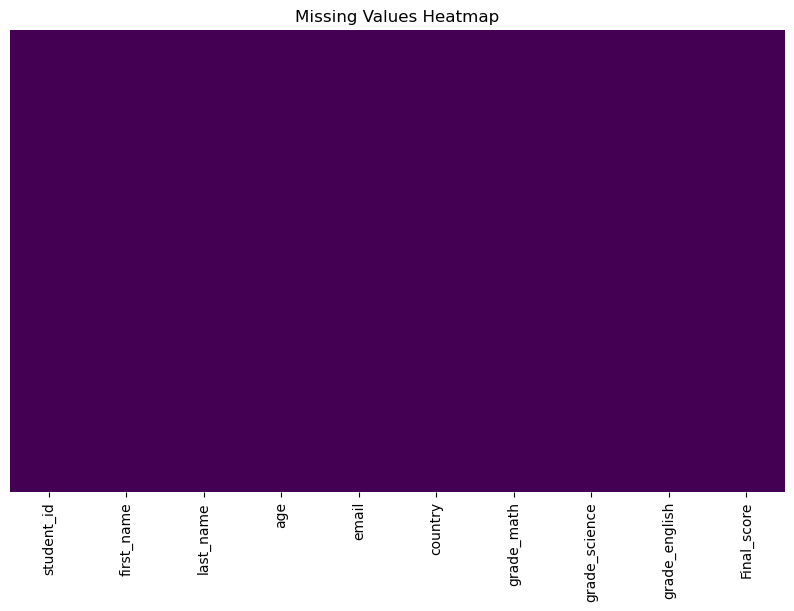

In [15]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(),
            cbar=False,
            yticklabels=False,
            cmap='viridis')

plt.title('Missing Values Heatmap')
plt.show()

In [16]:
# Count duplicate rows
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
0


In [17]:
# Remove duplicates
df = df.drop_duplicates()

# Verify duplicates removed
print("Duplicate Rows After Removal:")
print(df.duplicated().sum())

Duplicate Rows After Removal:
0


In [18]:
print(df.dtypes)

student_id        int64
first_name       object
last_name        object
age               int64
email            object
country          object
grade_math        int64
grade_science     int64
grade_english     int64
Final_score       int64
dtype: object


In [19]:
# Convert country names to lowercase
df['country'] = df['country'].str.lower().str.strip()

# Convert first and last names to lowercase
df['first_name'] = df['first_name'].str.lower().str.strip()
df['last_name'] = df['last_name'].str.lower().str.strip()

# Display updated dataset
print(df.head())

   student_id first_name   last_name  age                        email  \
0           1    kerrill   de cleyne   24          kdecleyne0@furl.net   
1           2    krissie      vittet   25          kvittet1@ustream.tv   
2           3   hugibert       haugg   21      hhaugg2@theguardian.com   
3           4     fancie     de mars   18       fdemars3@parallels.com   
4           5      micki  o'dowgaine   24  modowgaine4@livejournal.com   

       country  grade_math  grade_science  grade_english  Final_score  
0    venezuela          68             80             15           54  
1     bulgaria          29             30             60           39  
2  new zealand          76              0             55           43  
3        china          82             88             90           86  
4        china          77             23             11           37  


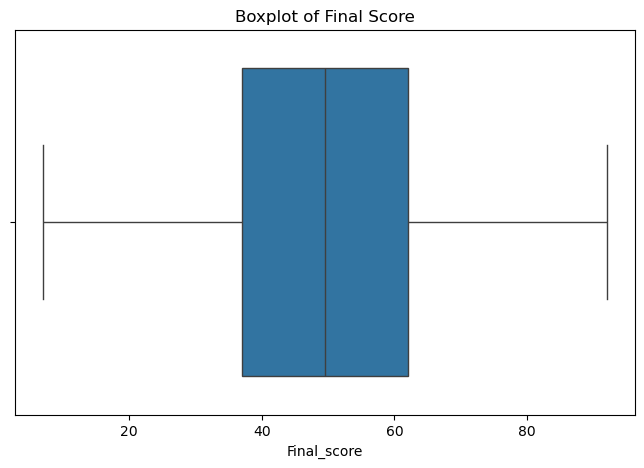

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Final_score'])

plt.title('Boxplot of Final Score')
plt.show()

In [21]:
# Calculate Q1 and Q3
Q1 = df['Final_score'].quantile(0.25)
Q3 = df['Final_score'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 37.0
Q3: 62.0
IQR: 25.0


In [22]:
# Remove outliers
clean_df = df[
    ~((df['Final_score'] < (Q1 - 1.5 * IQR)) |
      (df['Final_score'] > (Q3 + 1.5 * IQR)))
]

print("Original Shape:", df.shape)
print("Shape After Outlier Removal:", clean_df.shape)

Original Shape: (1000, 10)
Shape After Outlier Removal: (1000, 10)


In [23]:
# Calculate z-scores
z_scores = np.abs(stats.zscore(df['Final_score']))

# Keep rows with z-score less than 3
zscore_df = df[(z_scores < 3)]

print("Original Shape:", df.shape)
print("Shape After Z-Score Filtering:", zscore_df.shape)

Original Shape: (1000, 10)
Shape After Z-Score Filtering: (1000, 10)
